In [4]:
import pandas as pd
analysis_data = pd.read_csv("pff_data_updated.csv")

In [5]:
analysis_data.head(20)

,Unnamed: 0,player,position,team_name,player_game_count,forced_fumbles,grades_coverage_defense,grades_defense,grades_defense_penalty,grades_pass_rush_defense,...,snap_counts_dl_b_gap,snap_counts_dl_outside_t,snap_counts_dl_over_t,snap_counts_pass_rush,snap_counts_run_defense,stops,tackles,tackles_for_loss,targets,total_pressures
0,NaN,Jackson Forrest,LB,DOMINION,11,3,83.3,88.5,83.5,87.8,...,0,0,0,49,125,20,25,3,8,13
1,NaN,Kris Jones,ED,GEORGIA,12,0,57.7,60.8,83.7,64.8,...,0,107,2,50,46,1,4,1,1,5
2,NaN,Carson Tujague,DI,UTAH ST,12,0,55.9,57.8,16.9,53.1,...,65,178,385,325,300,26,33,2,4,12
3,NaN,Sahir West,ED,JAMES MAD,13,0,63.2,73.3,34.9,70.1,...,70,357,78,288,216,19,19,5,0,25
4,NaN,Chris Forbes,DI,DOMINION,12,0,71.1,63.4,61.7,58.6,...,79,158,83,184,185,15,15,4,0,9
5,NaN,Lorenzo McFadden-Pressley,DI,DOMINION,9,0,60.0,58.5,27.3,64.1,...,18,0,1,49,70,2,2,0,0,3
6,NaN,Bryce Deas,LB,AUBURN,9,0,77.2,74.3,84.9,58.8,...,0,82,0,26,87,7,10,2,7,8
7,NaN,Bryce Jenkins,DI,MARYLAND,8,0,60.0,63.0,0.0,58.7,...,101,0,2,64,87,4,5,1,0,2
8,NaN,Carlton Smith,LB,MARYLAND,12,0,33.8,57.7,81.3,64.9,...,0,4,0,29,214,23,48,2,22,7
9,NaN,Nahsir Taylor,ED,MARYLAND,11,0,60.4,65.7,9.2,78.5,...,0,265,2,135,129,10,12,1,1,12


In [9]:
analysis_data = analysis_data.drop(columns=['Unnamed: 0'])

In [11]:
analysis_data.columns

Index(['player', 'position', 'team_name', 'player_game_count',
       'forced_fumbles', 'grades_coverage_defense', 'grades_defense',
       'grades_defense_penalty', 'grades_pass_rush_defense',
       'grades_run_defense', 'grades_tackle', 'hits', 'hurries',
       'missed_tackle_rate', 'missed_tackles', 'pass_break_ups', 'penalties',
       'qb_rating_against', 'sacks', 'snap_counts_box', 'snap_counts_coverage',
       'snap_counts_defense', 'snap_counts_dl', 'snap_counts_dl_a_gap',
       'snap_counts_dl_b_gap', 'snap_counts_dl_outside_t',
       'snap_counts_dl_over_t', 'snap_counts_pass_rush',
       'snap_counts_run_defense', 'stops', 'tackles', 'tackles_for_loss',
       'targets', 'total_pressures'],
      dtype='object')

Subsetting by grades and stats

In [12]:
analysis_grades = analysis_data[["player", "position", "grades_defense", "grades_pass_rush_defense", "grades_run_defense", "grades_tackle"]]
analysis_stats_raw = analysis_data[["player", "position", "snap_counts_defense", "tackles", "total_pressures", "hits", "hurries", "missed_tackles", "sacks", "snap_counts_pass_rush"
                                    ,"snap_counts_run_defense"]]

Adding in metrics relative to production (already factored into grades)

In [14]:
# calculating stats per snap
analysis_stats_normalized = analysis_stats_raw.copy()
for stat in ["tackles", "total_pressures", "hits", "hurries", "sacks", "missed_tackles"]:
    analysis_stats_normalized[f"{stat}_per_100_snaps"] = round(analysis_stats_normalized[stat] * 100 / analysis_stats_normalized["snap_counts_defense"], 3)

In [15]:
analysis_stats_normalized.head()

,player,position,snap_counts_defense,tackles,total_pressures,hits,hurries,missed_tackles,sacks,snap_counts_pass_rush,snap_counts_run_defense,tackles_per_100_snaps,total_pressures_per_100_snaps,hits_per_100_snaps,hurries_per_100_snaps,sacks_per_100_snaps,missed_tackles_per_100_snaps
0,Jackson Forrest,LB,273,25,13,1,7,7,5,49,125,9.158,4.762,0.366,2.564,1.832,2.564
1,Kris Jones,ED,115,4,5,0,5,1,0,50,46,3.478,4.348,0.000,4.348,0.000,0.870
2,Carson Tujague,DI,644,33,12,3,8,3,1,325,300,5.124,1.863,0.466,1.242,0.155,0.466
3,Sahir West,ED,507,19,25,5,16,3,4,288,216,3.748,4.931,0.986,3.156,0.789,0.592
4,Chris Forbes,DI,369,15,9,1,6,2,2,184,185,4.065,2.439,0.271,1.626,0.542,0.542


In [17]:
# sorting data by position and overall grade
analysis_grades_sorted = analysis_grades.sort_values(by=["position", "grades_defense"], ascending=[True, False])

In [18]:
analysis_grades_sorted.head(25)

,player,position,grades_defense,grades_pass_rush_defense,grades_run_defense,grades_tackle
4,Chris Forbes,DI,63.4,58.6,62.1,59.5
7,Bryce Jenkins,DI,63.0,58.7,74.2,63.0
11,Hunter Malecki,DI,60.5,60.5,53.7,43.1
5,Lorenzo McFadden-Pressley,DI,58.5,64.1,58.0,57.0
2,Carson Tujague,DI,57.8,53.1,67.5,78.2
3,Sahir West,ED,73.3,70.1,74.2,76.5
13,Zahir Mathis,ED,68.6,74.0,63.5,66.5
12,Yvan Kemajou,ED,67.0,64.9,65.5,73.9
9,Nahsir Taylor,ED,65.7,78.5,56.2,28.7
10,Sidney Stewart,ED,63.3,74.9,60.8,50.0


# Ben's Section

Players:
- Jackson Forrest
- Sahir West
- Zahir Mathis	
- Bryce Deas

In [36]:
subset_players_1 = ['Jackson Forrest', 'Sahir West', 'Zahir Mathis', 'Bryce Deas']
subset_analysis_1 = analysis_stats_normalized[analysis_stats_normalized['player'].isin(subset_players_1)]

In [31]:
subset_analysis_1

,player,position,snap_counts_defense,tackles,total_pressures,hits,hurries,missed_tackles,sacks,snap_counts_pass_rush,snap_counts_run_defense,tackles_per_100_snaps,total_pressures_per_100_snaps,hits_per_100_snaps,hurries_per_100_snaps,sacks_per_100_snaps,missed_tackles_per_100_snaps
0,Jackson Forrest,LB,273,25,13,1,7,7,5,49,125,9.158,4.762,0.366,2.564,1.832,2.564
1,Kris Jones,ED,115,4,5,0,5,1,0,50,46,3.478,4.348,0.000,4.348,0.000,0.870
2,Carson Tujague,DI,644,33,12,3,8,3,1,325,300,5.124,1.863,0.466,1.242,0.155,0.466
3,Sahir West,ED,507,19,25,5,16,3,4,288,216,3.748,4.931,0.986,3.156,0.789,0.592


In [37]:
subset_grades_1 = analysis_grades[analysis_grades['player'].isin(subset_players_1)]
subset_grades_1

,player,position,grades_defense,grades_pass_rush_defense,grades_run_defense,grades_tackle
0,Jackson Forrest,LB,88.5,87.8,69.0,55.8
3,Sahir West,ED,73.3,70.1,74.2,76.5
6,Bryce Deas,LB,74.3,58.8,71.2,55.2
13,Zahir Mathis,ED,68.6,74.0,63.5,66.5


- Make plots of assists, tackles, hurries, sacks, and pressures per 100 snaps
- Look at each players PFF grades
- Analyze athleticism (metrics), what may 'contribute to long-term success'
- Brief write up about individual player profiles (include profiling, athleticism, grades, stats, likelihood of transferring)

In [38]:
analysis_stats_normalized.columns

Index(['player', 'position', 'snap_counts_defense', 'tackles',
       'total_pressures', 'hits', 'hurries', 'missed_tackles', 'sacks',
       'snap_counts_pass_rush', 'snap_counts_run_defense',
       'tackles_per_100_snaps', 'total_pressures_per_100_snaps',
       'hits_per_100_snaps', 'hurries_per_100_snaps', 'sacks_per_100_snaps',
       'missed_tackles_per_100_snaps'],
      dtype='object')

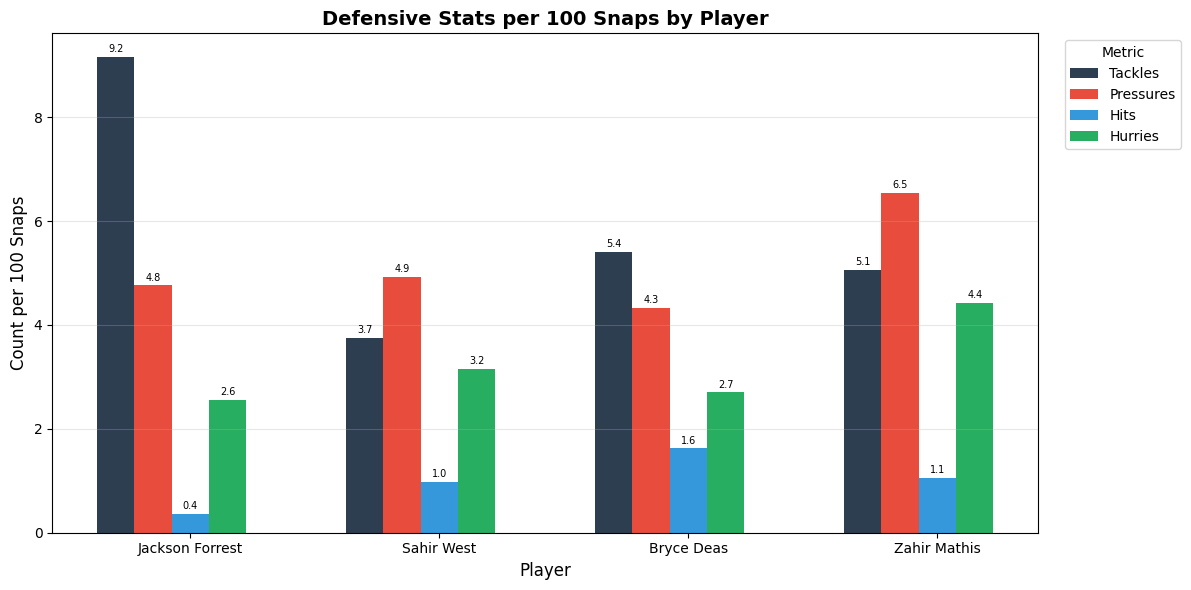

In [42]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

players = subset_analysis_1['player']
metrics = ['tackles_per_100_snaps', 'total_pressures_per_100_snaps', 
           'hits_per_100_snaps', 'hurries_per_100_snaps']
labels = ['Tackles', 'Pressures', 'Hits', 'Hurries']

x = np.arange(len(players))
width = 0.15
colors = ['#2c3e50', '#e74c3c', '#3498db', '#27ae60']

for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    offset = (i - 2) * width
    bars = ax.bar(x + offset, subset_analysis_1[metric], width, label=label, color=color)
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)

ax.set_xlabel('Player', fontsize=12)
ax.set_ylabel('Count per 100 Snaps', fontsize=12)
ax.set_title('Defensive Stats per 100 Snaps by Player', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(players, fontsize=10)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

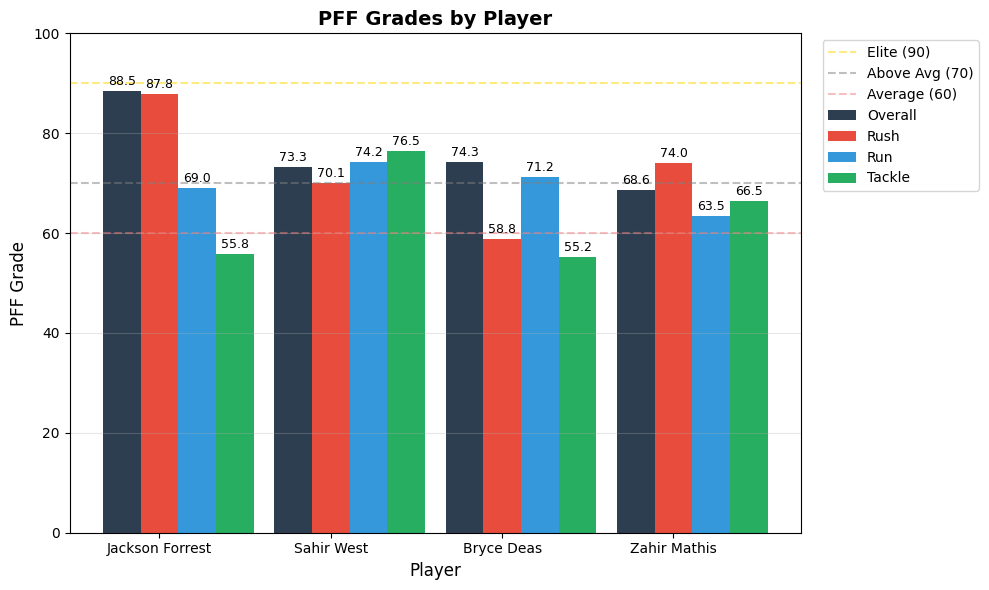

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

players = subset_grades_1['player']
grade_cols = ['grades_defense', 'grades_pass_rush_defense', 'grades_run_defense', 'grades_tackle']
grade_labels = ['Overall', 'Rush', 'Run', 'Tackle']
colors = ['#2c3e50', '#e74c3c', '#3498db', '#27ae60']

x = np.arange(len(players))
width = 0.22

for i, (col, label, color) in enumerate(zip(grade_cols, grade_labels, colors)):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, subset_grades_1[col], width, label=label, color=color)
    ax.bar_label(bars, fmt='%.1f', fontsize=9, padding=2)

# Reference lines for PFF grade tiers
ax.axhline(y=90, color='gold', linestyle='--', alpha=0.5, label='Elite (90)')
ax.axhline(y=70, color='gray', linestyle='--', alpha=0.5, label='Above Avg (70)')
ax.axhline(y=60, color='lightcoral', linestyle='--', alpha=0.5, label='Average (60)')

ax.set_xlabel('Player', fontsize=12)
ax.set_ylabel('PFF Grade', fontsize=12)
ax.set_title('PFF Grades by Player', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(players, fontsize=10)
ax.set_ylim(0, 100)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Jackson Forrest:
- Linebacker from ODU originally from North Carolina and a 3 star recruit coming out of high school
- Played in all 13 games last year
- 8.1 tackles/100 snaps which is very strong, also may be due to the fact that he is a linebacker
- 6 feet tall 225 pounds
- Graded out as a 88.5 overall PFF grade, strong as a pass rushing linebacker, high volume tackler

Sahir West
- Defensive lineman playing for JMU, originally from Baltimore (strong DMV ties)
- Won Sun Belt Conference Freshman of the Year, first team all american from the Athletic
- Started all 14 games at DE
- 7 sacks put him fifth in the Sunbelt overall
- 4.9 pressures/100 snaps, pretty solid
- Very well rounded player, plays in pass coverage as well as rushing the passer and stopping the run

Bryce Deas
- 6'1 210 pound linebacker from Maryland
- Appeared in 11 games, started in 1
- Grades out as an above average player, strongest in run stopping and pass coverage
- Solid tackler, 1.6 QB hits/100 snaps is strong
- Underperforms in pressures/hurries, is a linebacker so may be less of a pass rusher

Zahir Mathis
- 6'6 225 pound lineman playing from Maryland
- Had offers from Ohio State, Florida State, Michigan and Penn State (4-star recruit)
- 247Sports True Freshman All-American, On3 True Freshman All-American
- Second on team with 6 sacks, 8.5 TFL
- Overall balanced player, defensive lineman who can get to the quarterback
- Best at rushing the passer, 74 PFF grade
- Really impressive 6.5 hurries/100 snaps